In [1]:
from __future__ import annotations
import hashlib, json, logging, re, unicodedata
from datetime import datetime, timezone
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
import umap.umap_ as umap

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("mplads_feature3")
pd.set_option("display.max_columns", 100)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount("/content/drive")

DEFAULT_COLAB_ROOT = Path("/content/drive/MyDrive/MPLADs")
alt_colab_root = Path("/content/drive/MYDrive/MPLADs")
if DEFAULT_COLAB_ROOT.exists():
    PROJECT_ROOT = DEFAULT_COLAB_ROOT
elif alt_colab_root.exists():
    PROJECT_ROOT = alt_colab_root
else:
    PROJECT_ROOT = Path.cwd()

SHARED_ARTIFACT_DIR = PROJECT_ROOT / "shared_preprocessing_artifacts"
OUTPUT_DIR = PROJECT_ROOT / "feature3_artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
assert SHARED_ARTIFACT_DIR.exists(), f"Missing {SHARED_ARTIFACT_DIR}; run SharedPreprocessing.ipynb first."
print(PROJECT_ROOT, SHARED_ARTIFACT_DIR, OUTPUT_DIR)

Mounted at /content/drive
/content/drive/MyDrive/MPLADs /content/drive/MyDrive/MPLADs/shared_preprocessing_artifacts /content/drive/MyDrive/MPLADs/feature3_artifacts


In [4]:
def read_artifact(name):
    parquet = SHARED_ARTIFACT_DIR / f"{name}.parquet"
    csv = SHARED_ARTIFACT_DIR / f"{name}.csv"
    if parquet.exists(): return pd.read_parquet(parquet)
    if csv.exists(): return pd.read_csv(csv)
    raise FileNotFoundError(f"Missing {parquet.name} and {csv.name}")

fact_work = read_artifact("fact_work")
required = ["work_key","work_id","work_raw","work_description_clean","work_category_raw","category_raw","category_nlp","house","state_key"]
missing = [c for c in required if c not in fact_work.columns]
if missing: raise ValueError(f"fact_work missing: {missing}")
assert fact_work.work_key.is_unique and fact_work.work_id.notna().all()

def clean_text(value):
    if pd.isna(value): return None
    text = unicodedata.normalize("NFKC", str(value)).replace("\xa0"," ").replace("\t"," ")
    text = re.sub(r"\s+", " ", text).strip().lower()
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    text = re.sub(r"\s+", " ", text).strip()
    return None if not text or text in {"na","n a","nan","none","null","-"} else text

def work_trailing_text(value):
    if pd.isna(value): return None
    text = re.sub(r"^\s*WS\s*/\s*MP\d+\s*/\s*\d{4}-\d{4}\s*/\s*\d+\s*-\s*", "", str(value), flags=re.I)
    return text.strip() if text.strip() else None

fact_work["nlp_description"] = fact_work["work_description_clean"].map(clean_text)
fact_work["nlp_description_source"] = np.where(fact_work.nlp_description.notna(), "work_description_clean", "unavailable")
missing_text = fact_work.nlp_description.isna()
fact_work.loc[missing_text, "nlp_description"] = fact_work.loc[missing_text, "work_raw"].map(work_trailing_text).map(clean_text)
fact_work.loc[missing_text & fact_work.nlp_description.notna(), "nlp_description_source"] = "work_raw_trailing_text"

print("rows:", len(fact_work), "usable:", fact_work.nlp_description.notna().sum(), "unavailable:", fact_work.nlp_description.isna().sum())

rows: 43150 usable: 43150 unavailable: 0


,word_count,character_count
count,43150.000000,43150.000000
mean,15.049571,91.067439
std,8.512718,50.296428
min,1.000000,1.000000
10%,7.000000,38.000000
50%,14.000000,83.000000
90%,25.000000,148.000000
99%,43.000000,260.000000
max,105.000000,499.000000


Share under five words: 0.040903823870220166


,count
category_raw,
Normal/Others,42274
Repair and Renovation,552
Trust and Society,314
<missing>,7
Bar and Associations,3


,share
language_mix,
latin_only_or_transliterated,0.999768
mixed,0.000232


,work_key,nlp_description,category_raw
7462,LS|WS/MP18188/2025-2026/159817,laying of cc road from j laxmamma h to kammari...,Normal/Others
624,LS|WS/MP18011/2025-2026/210140,drilling of a new borewell for scheme source n...,Normal/Others
25087,LS|WS/MP814/2025-2026/178585,construction of c c road from amar singh house...,Normal/Others
14553,LS|WS/MP18346/2024-2025/162465,installation of solar light at near resident o...,Normal/Others
33090,RS|WS/MP18283/2025-2026/229794,construction of budheswar youth community cent...,Normal/Others
8786,LS|WS/MP18213/2025-2026/194179,etah shikohabad road par shiva garden marriage...,Normal/Others
41055,RS|WS/MP838/2026-2027/242203,to carry out the construction work of a concre...,Normal/Others
6573,LS|WS/MP18166/2024-2025/164823,interlocking block road construction work in f...,Normal/Others
28616,RS|WS/MP084/2025-2026/38659,12 12 5 meter high mast light installation work,Normal/Others
11335,LS|WS/MP18230/2024-2025/148533,sri bechalal yadav mawai churaha ke ghar ke pa...,Normal/Others


,count
road,9137
light,9079
school,3590
solar,3509
water,2167
drain,660
toilet,255
hospital,250
ambulance,140


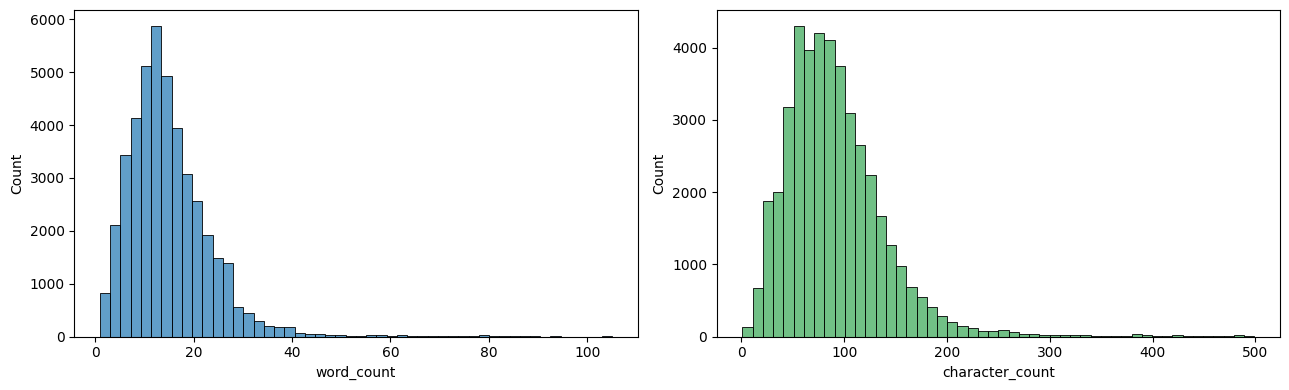

In [5]:
usable = fact_work[fact_work.nlp_description.notna()].copy()
usable["word_count"] = usable.nlp_description.str.split().str.len()
usable["character_count"] = usable.nlp_description.str.len()
display(usable[["word_count","character_count"]].describe(percentiles=[.1,.5,.9,.99]))
print("Share under five words:", (usable.word_count < 5).mean())
display(fact_work.category_raw.fillna("<missing>").value_counts().head(20).to_frame("count"))

def mix_bucket(text):
    words = text.split()
    ascii_words = sum(bool(re.fullmatch(r"[a-z0-9]+", w)) for w in words)
    if ascii_words == len(words): return "latin_only_or_transliterated"
    if ascii_words == 0: return "non_latin"
    return "mixed"

usable["language_mix"] = usable.nlp_description.map(mix_bucket)
display(usable.language_mix.value_counts(normalize=True).rename("share").to_frame())
review_sample = usable[["work_key","nlp_description","category_raw"]].sample(min(100,len(usable)), random_state=42)
review_sample.to_csv(OUTPUT_DIR/"description_manual_review_sample.csv", index=False)
display(review_sample.head(25))

keywords = ["road","light","water","school","ambulance","solar","hospital","drain","toilet"]
keyword_counts = {k:int(usable.nlp_description.str.contains(rf"\b{re.escape(k)}\b", na=False).sum()) for k in keywords}
display(pd.Series(keyword_counts, name="count").sort_values(ascending=False).to_frame())
fig, axes = plt.subplots(1,2, figsize=(13,4))
sns.histplot(usable.word_count, bins=50, ax=axes[0], color="#2c7fb8")
sns.histplot(usable.character_count, bins=50, ax=axes[1], color="#41ab5d")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"description_length_eda.png", dpi=160); plt.show()

In [6]:
description_catalog = usable[["nlp_description"]].drop_duplicates().reset_index(drop=True)
description_catalog["description_uid"] = np.arange(len(description_catalog))
fact_work = fact_work.merge(description_catalog, on="nlp_description", how="left", validate="many_to_one")
fact_work["description_uid"] = fact_work.description_uid.astype("Int64")
print("Unique texts to embed:", len(description_catalog))

EMBEDDING_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
try:
    embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device="cuda")
    EMBEDDING_DEVICE = "cuda"
except Exception as exc:
    print("GPU unavailable; using CPU:", exc)
    embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device="cpu")
    EMBEDDING_DEVICE = "cpu"

embeddings = embedding_model.encode(
    description_catalog.nlp_description.tolist(), batch_size=64,
    show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True
).astype("float32")
np.save(OUTPUT_DIR/"description_embeddings.npy", embeddings)
embedding_model.save(str(OUTPUT_DIR / "feature3_sentence_transformer"))
print("Embedding matrix:", embeddings.shape)

Unique texts to embed: 38041


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

GPU unavailable; using CPU: Torch not compiled with CUDA enabled


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/595 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding matrix: (38041, 384)


In [7]:
UMAP_COMPONENTS, UMAP_NEIGHBORS, UMAP_MIN_DIST = 15, 30, 0.0
HDBSCAN_MIN_CLUSTER_SIZE, HDBSCAN_MIN_SAMPLES = 30, 10
if len(description_catalog) <= UMAP_NEIGHBORS: raise ValueError("Too few unique descriptions.")

reducer = umap.UMAP(n_components=UMAP_COMPONENTS, n_neighbors=UMAP_NEIGHBORS, min_dist=UMAP_MIN_DIST, metric="cosine", random_state=42)
reduced = reducer.fit_transform(embeddings)
clusterer = HDBSCAN(min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE, min_samples=HDBSCAN_MIN_SAMPLES,
                    metric="euclidean", cluster_selection_method="eom", prediction_data=True)
labels = clusterer.fit_predict(reduced)
description_catalog["cluster_id"] = labels.astype(int)
description_catalog["cluster_membership_probability"] = clusterer.probabilities_
non_noise = labels >= 0
cluster_count = int(len(set(labels[non_noise]))) if non_noise.any() else 0
noise_rate = float((~non_noise).mean())
print("Non-noise clusters:", cluster_count, "noise rate:", noise_rate)
display(description_catalog.cluster_id.value_counts().head(20).to_frame("unique_description_count"))
if cluster_count >= 2 and non_noise.sum() >= 10:
    idx = np.flatnonzero(non_noise)
    if len(idx) > 10000: idx = np.random.default_rng(42).choice(idx, 10000, replace=False)
    print("Silhouette:", silhouette_score(reduced[idx], labels[idx]))
joblib.dump(reducer, OUTPUT_DIR/"feature3_umap.joblib")
joblib.dump(clusterer, OUTPUT_DIR/"feature3_hdbscan.joblib")

Non-noise clusters: 304 noise rate: 0.25780079388028704


,unique_description_count
cluster_id,
-1,9807
92,916
257,777
267,523
187,508
240,412
18,401
23,358
238,323


Silhouette: 0.70385987


['/content/drive/MyDrive/MPLADs/feature3_artifacts/feature3_hdbscan.joblib']

In [8]:
def representative_rows(cluster_id, n=8):
    members = description_catalog[description_catalog.cluster_id.eq(cluster_id)].copy()
    idx = members.index.to_numpy()
    centroid = reduced[idx].mean(axis=0)
    members["distance_to_centroid"] = np.linalg.norm(reduced[idx] - centroid, axis=1)
    return members.sort_values("distance_to_centroid").head(n)

review_rows = []
for cluster_id in sorted(description_catalog.loc[description_catalog.cluster_id >= 0, "cluster_id"].unique()):
    members = description_catalog[description_catalog.cluster_id.eq(cluster_id)]
    reps = representative_rows(int(cluster_id))
    review_rows.append({
        "cluster_id": int(cluster_id),
        "unique_description_count": int(len(members)),
        "representative_descriptions": " || ".join(reps.nlp_description.tolist()),
    })
cluster_review = pd.DataFrame(review_rows).sort_values("unique_description_count", ascending=False)
cluster_review.to_csv(OUTPUT_DIR/"feature3_cluster_review.csv", index=False)
display(cluster_review.head(30))

,cluster_id,unique_description_count,representative_descriptions
92,92,916,formation and strengthening of r s embankment ...
257,257,777,construction of cc road from durga matha templ...
267,267,523,construction of community hall at jemadeipur v...
187,187,508,construction of pcc road from durga mandir to ...
240,240,412,construction of concrete road from harijan bas...
18,18,401,vijay patel s o raj nath patel k ghar 01 nag s...
23,23,358,construction of toilet block at gobra jumma ma...
238,238,323,construction of community center in ward no 89...
251,251,310,construction of c c road from the house of sri...
196,196,309,providing led high mast light near mahalaxmi t...


In [9]:
PROVISIONAL_TAXONOMY = {
    "Road & Pathway Infrastructure": {
        "prototype": "construction and repair of roads pathways paver blocks bridges culverts and approach roads",
        "keywords": ["road", "pathway", "paver", "culvert", "bridge", "cc road", "cement road"],
    },
    "Street Lighting & Solar Energy": {
        "prototype": "street lights solar lights high mast lights LED lights and public lighting",
        "keywords": ["light", "lighting", "solar", "led", "high mast", "street lamp"],
    },
    "Drinking Water Infrastructure": {
        "prototype": "drinking water supply hand pumps bore wells pipelines pumping machinery and water distribution",
        "keywords": ["drinking water", "water supply", "hand pump", "borewell", "bore well", "pipeline", "pumping"],
    },
    "Sanitation & Drainage": {
        "prototype": "drainage sewer sanitation toilets and waste management infrastructure",
        "keywords": ["drain", "drainage", "sewer", "toilet", "sanitation", "waste"],
    },
    "School & Education Infrastructure": {
        "prototype": "school classroom education college library laboratory and educational infrastructure",
        "keywords": ["school", "classroom", "college", "library", "laboratory", "education"],
    },
    "Healthcare & Ambulance Services": {
        "prototype": "hospital health centre medical equipment ambulance and healthcare infrastructure",
        "keywords": ["hospital", "health", "medical", "ambulance", "clinic", "healthcare"],
    },
    "Community & Public Buildings": {
        "prototype": "community hall public building shelter office and civic infrastructure",
        "keywords": ["community hall", "community center", "building", "shelter", "public hall", "anganwadi"],
    },
    "Agriculture & Irrigation": {
        "prototype": "irrigation agriculture farm water harvesting and rural agricultural infrastructure",
        "keywords": ["irrigation", "agriculture", "farm", "canal", "check dam", "harvesting"],
    },
    "Sports & Recreation": {
        "prototype": "sports ground playground stadium and recreation facilities",
        "keywords": ["sport", "playground", "stadium", "gym", "recreation", "ground"],
    },
    "Religious & Cultural Infrastructure": {
        "prototype": "religious cultural heritage and public cultural facilities",
        "keywords": ["temple", "mandir", "mosque", "church", "cultural", "heritage"],
    },
    "Other Public Infrastructure": {
        "prototype": "other eligible public infrastructure and civic works",
        "keywords": ["public", "civic", "infrastructure"],
    },
}
PROTOTYPE_SEMANTIC_WEIGHT = 0.70
PROTOTYPE_KEYWORD_WEIGHT = 0.30
PROTOTYPE_CONFIDENCE_THRESHOLD = 0.55
TAXONOMY_CONFIG = {
    "taxonomy": PROVISIONAL_TAXONOMY,
    "semantic_weight": PROTOTYPE_SEMANTIC_WEIGHT,
    "keyword_weight": PROTOTYPE_KEYWORD_WEIGHT,
    "prototype_confidence_threshold": PROTOTYPE_CONFIDENCE_THRESHOLD,
}
TAXONOMY_VERSION = hashlib.sha256(
    json.dumps(TAXONOMY_CONFIG, sort_keys=True).encode("utf-8")
).hexdigest()[:12]
TAXONOMY_LABELS = list(PROVISIONAL_TAXONOMY)
with open(OUTPUT_DIR / "feature3_taxonomy_config.json", "w", encoding="utf-8") as file:
    json.dump({"taxonomy_version": TAXONOMY_VERSION, **TAXONOMY_CONFIG}, file, indent=2)

prototype_texts = [PROVISIONAL_TAXONOMY[label]["prototype"] for label in TAXONOMY_LABELS]
prototype_embeddings = embedding_model.encode(
    prototype_texts, convert_to_numpy=True, normalize_embeddings=True
).astype("float32")

def keyword_scores(texts, labels=TAXONOMY_LABELS):
    scores = np.zeros((len(texts), len(labels)), dtype="float32")
    for row_index, text in enumerate(texts):
        normalized = str(text).lower()
        for column_index, label in enumerate(labels):
            hits = sum(normalized.count(keyword) for keyword in PROVISIONAL_TAXONOMY[label]["keywords"])
            scores[row_index, column_index] = min(hits / 3.0, 1.0)
    return scores

def prototype_predictions(texts, vectors):
    semantic = np.asarray(vectors) @ prototype_embeddings.T
    semantic = np.clip((semantic + 1.0) / 2.0, 0.0, 1.0)
    combined = PROTOTYPE_SEMANTIC_WEIGHT * semantic + PROTOTYPE_KEYWORD_WEIGHT * keyword_scores(texts)
    # Softmax confidence expresses separation from the other provisional categories.
    probabilities = np.exp((combined - combined.max(axis=1, keepdims=True)) / 0.10)
    probabilities = probabilities / probabilities.sum(axis=1, keepdims=True)
    winners = probabilities.argmax(axis=1)
    return np.array(TAXONOMY_LABELS, dtype=object)[winners], probabilities.max(axis=1), combined

prototype_labels, prototype_confidence, prototype_matrix = prototype_predictions(
    description_catalog.nlp_description.tolist(), embeddings
)
description_catalog["prototype_label"] = prototype_labels
description_catalog["prototype_confidence"] = prototype_confidence

# For clustered descriptions, label each cluster by its centroid. Noise is labeled
# per-description using the same prototype scorer.
cluster_rows = []
cluster_label_lookup = {}
cluster_confidence_lookup = {}
for cluster_id in sorted(description_catalog.loc[description_catalog.cluster_id >= 0, "cluster_id"].unique()):
    member_indices = description_catalog.index[description_catalog.cluster_id.eq(cluster_id)].to_numpy()
    centroid = embeddings[member_indices].mean(axis=0)
    centroid = centroid / max(np.linalg.norm(centroid), 1e-12)
    texts = description_catalog.loc[member_indices, "nlp_description"].tolist()
    labels_for_cluster, confidence_for_cluster, matrix_for_cluster = prototype_predictions([" ".join(texts)], centroid[None, :])
    label = str(labels_for_cluster[0]) if confidence_for_cluster[0] >= PROTOTYPE_CONFIDENCE_THRESHOLD else "Unclassified"
    cluster_label_lookup[int(cluster_id)] = label
    cluster_confidence_lookup[int(cluster_id)] = float(confidence_for_cluster[0])
    cluster_rows.append({"cluster_id": int(cluster_id), "provisional_category": label, "confidence": float(confidence_for_cluster[0]), "unique_description_count": len(member_indices)})

description_catalog["cluster_label"] = description_catalog.cluster_id.map(cluster_label_lookup)
noise_mask = description_catalog.cluster_id.lt(0)
description_catalog.loc[noise_mask, "cluster_label"] = description_catalog.loc[noise_mask, "prototype_label"]
description_catalog.loc[description_catalog.cluster_label.isna(), "cluster_label"] = "Unclassified"
description_catalog.loc[description_catalog.cluster_id >= 0, "prototype_confidence"] = description_catalog.loc[description_catalog.cluster_id >= 0, "cluster_id"].map(cluster_confidence_lookup)
cluster_label_table = pd.DataFrame(
    cluster_rows,
    columns=["cluster_id", "provisional_category", "confidence", "unique_description_count"],
).sort_values("unique_description_count", ascending=False)
cluster_label_table.to_csv(OUTPUT_DIR / "feature3_provisional_cluster_labels.csv", index=False)
display(cluster_label_table.head(30))
print("Taxonomy version:", TAXONOMY_VERSION)

,cluster_id,provisional_category,confidence,unique_description_count
92,92,Unclassified,0.175773,916
257,257,Unclassified,0.261033,777
267,267,Unclassified,0.345836,523
187,187,Unclassified,0.287955,508
240,240,Unclassified,0.379335,412
18,18,Street Lighting & Solar Energy,0.688140,401
23,23,Unclassified,0.312213,358
238,238,Unclassified,0.330427,323
251,251,Unclassified,0.456633,310
196,196,Unclassified,0.530130,309


Taxonomy version: c0163441e8b5


In [10]:
training = description_catalog[
    description_catalog.cluster_label.notna()
    & description_catalog.prototype_confidence.ge(PROTOTYPE_CONFIDENCE_THRESHOLD)
    & description_catalog.cluster_label.ne("Unclassified")
].copy()
counts = training.cluster_label.value_counts()
training = training[training.cluster_label.isin(counts[counts >= 2].index)]
if training.cluster_label.nunique() < 2:
    category_classifier = None
    print("Fewer than two reliable provisional categories; prototype scoring will be used for this run.")
else:
    X_train, X_valid, y_train, y_valid = train_test_split(
        training.nlp_description, training.cluster_label, test_size=.20, random_state=42, stratify=training.cluster_label
    )
    category_classifier = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=100_000, sublinear_tf=True)),
        ("classifier", LGBMClassifier(
            objective="multiclass", n_estimators=300, learning_rate=0.05,
            num_leaves=31, class_weight="balanced", random_state=42,
            verbosity=-1,
        )),
    ])
    category_classifier.fit(X_train, y_train)
    pred = category_classifier.predict(X_valid)
    print("Validation accuracy:", accuracy_score(y_valid, pred))
    print(classification_report(y_valid, pred, zero_division=0))
    joblib.dump(category_classifier, OUTPUT_DIR/"feature3_tfidf_lightgbm_classifier.joblib")

Validation accuracy: 0.9776902887139107
                                     precision    recall  f1-score   support

           Agriculture & Irrigation       1.00      0.97      0.98        30
       Community & Public Buildings       0.96      0.95      0.96        84
      Drinking Water Infrastructure       0.96      0.90      0.93        59
    Healthcare & Ambulance Services       0.82      0.80      0.81        40
Religious & Cultural Infrastructure       0.94      0.95      0.94       128
      Road & Pathway Infrastructure       0.97      0.99      0.98       405
              Sanitation & Drainage       1.00      0.80      0.89        20
  School & Education Infrastructure       0.98      0.98      0.98       309
                Sports & Recreation       0.95      0.95      0.95        44
     Street Lighting & Solar Energy       0.99      0.99      0.99      1167

                           accuracy                           0.98      2286
                          macro av

In [12]:
CATEGORY_CONFIDENCE_THRESHOLD = PROTOTYPE_CONFIDENCE_THRESHOLD
categorized = fact_work.copy()
categorized["category_nlp"] = pd.NA
categorized["category_nlp_confidence"] = np.nan
categorized["category_nlp_cluster_id"] = pd.array([pd.NA]*len(categorized), dtype="Int64")
categorized["category_nlp_source"] = "unavailable"

valid = categorized.nlp_description.notna()
texts = categorized.loc[valid, "nlp_description"]
if category_classifier is None:
    predicted = np.array([None] * len(texts), dtype=object)
    classifier_confidence = np.zeros(len(texts), dtype=float)
else:
    predicted = category_classifier.predict(texts)
    probabilities = category_classifier.predict_proba(texts)
    classifier_confidence = probabilities.max(axis=1)
text_to_prototype = description_catalog.set_index("nlp_description")[["prototype_label", "prototype_confidence"]]
prototype_for_rows = text_to_prototype.loc[texts].reset_index(drop=True)
use_classifier = classifier_confidence >= CATEGORY_CONFIDENCE_THRESHOLD
use_prototype = (~use_classifier) & prototype_for_rows["prototype_confidence"].ge(CATEGORY_CONFIDENCE_THRESHOLD)
final_labels = np.where(
    use_classifier, predicted,
    np.where(use_prototype, prototype_for_rows["prototype_label"], "Unclassified"),
)
final_confidence = np.where(
    use_classifier, classifier_confidence,
    prototype_for_rows["prototype_confidence"].to_numpy(),
)
final_source = np.where(use_classifier, "lightgbm_classifier", np.where(use_prototype, "prototype_fallback", "low_confidence"))
categorized.loc[valid, "category_nlp_confidence"] = final_confidence
categorized.loc[valid, "category_nlp"] = final_labels
categorized.loc[valid, "category_nlp_source"] = final_source
text_to_cluster = description_catalog.set_index("nlp_description").cluster_id
categorized.loc[valid, "category_nlp_cluster_id"] = texts.map(text_to_cluster).astype("Int64")
categorized["category_nlp_model_version"] = TAXONOMY_VERSION + " + " + EMBEDDING_MODEL_NAME + " + UMAP/HDBSCAN + TFIDF/LightGBM"
print("Assigned categories:", int(categorized.category_nlp.notna().sum()))
display(categorized[["work_id","nlp_description","category_nlp","category_nlp_confidence","category_nlp_cluster_id"]].head(20))

Assigned categories: 43150


,work_id,nlp_description,category_nlp,category_nlp_confidence,category_nlp_cluster_id
0,WS/MP005/2024-2025/145074,construction of c c road at bhalan para vistar...,Road & Pathway Infrastructure,0.999999,251
1,WS/MP005/2024-2025/175217,construction of c c road work at main road tow...,Road & Pathway Infrastructure,1.000000,251
2,WS/MP005/2024-2025/175218,construction of paver block work at somnath ma...,Road & Pathway Infrastructure,0.979786,247
3,WS/MP005/2024-2025/175230,construction of paver block work at bharatpura...,Road & Pathway Infrastructure,0.965968,247
4,WS/MP005/2024-2025/175232,construction of paver block work at bharatpura...,Road & Pathway Infrastructure,0.999810,247
5,WS/MP005/2024-2025/175233,construction of paver block work and compound ...,Road & Pathway Infrastructure,1.000000,247
6,WS/MP005/2024-2025/175247,construction of c c road work at gayatrinagr m...,Road & Pathway Infrastructure,0.999946,-1
7,WS/MP005/2024-2025/175248,construction of c c road work at gayatringar p...,Road & Pathway Infrastructure,0.999993,243
8,WS/MP005/2024-2025/175249,remaining work construction of c c road work a...,Road & Pathway Infrastructure,1.000000,251
9,WS/MP005/2024-2025/175250,construction of c c road work at palla rajubha...,Road & Pathway Infrastructure,1.000000,251


In [13]:
def normalize_category(value):
    if pd.isna(value): return None
    text = re.sub(r"\s+", " ", str(value).upper()).strip()
    return text if text and text not in {"NA","N/A","NONE","NULL"} else None

categorized["declared_category_normalized"] = categorized.category_raw.map(normalize_category)
categorized["category_nlp_normalized"] = categorized.category_nlp.map(normalize_category)
GENERIC_DECLARED_CATEGORIES = {"NORMAL/OTHERS","NORMAL","OTHERS","OTHER"}
explicit = categorized.declared_category_normalized.notna() & ~categorized.declared_category_normalized.isin(GENERIC_DECLARED_CATEGORIES)
confident = categorized.category_nlp_confidence.ge(.70)
categorized["category_mismatch_flag"] = (
    explicit & confident & categorized.category_nlp_normalized.notna()
    & ~categorized.category_nlp_normalized.eq(categorized.declared_category_normalized)
)
categorized["category_mismatch_confidence"] = np.where(categorized.category_mismatch_flag, categorized.category_nlp_confidence, np.nan)
categorized["category_mismatch_reason"] = np.select(
    [categorized.category_mismatch_flag, categorized.category_nlp.isna(), ~explicit],
    ["Confident NLP category disagrees with explicit declared category",
     "No sufficiently confident NLP category",
     "Declared category is missing or generic catch-all"],
    default="No mismatch detected",
)
print("Mismatch flags:", int(categorized.category_mismatch_flag.sum()))
display(categorized.loc[categorized.category_mismatch_flag, [
    "work_id","nlp_description","category_raw","category_nlp","category_nlp_confidence","category_mismatch_reason"
]].head(25))

Mismatch flags: 745


,work_id,nlp_description,category_raw,category_nlp,category_nlp_confidence,category_mismatch_reason
135,WS/MP013/2024-2025/137612,restoration of protective work at rumtek ariga...,Repair and Renovation,Street Lighting & Solar Energy,0.961942,Confident NLP category disagrees with explicit...
220,WS/MP021/2025-2026/192575,janpad nainital ke antargat gram bharatpur num...,Repair and Renovation,Religious & Cultural Infrastructure,0.999999,Confident NLP category disagrees with explicit...
271,WS/MP18003/2024-2025/172286,providing roof slab to community hall at 39th ...,Repair and Renovation,Community & Public Buildings,1.000000,Confident NLP category disagrees with explicit...
272,WS/MP18003/2024-2025/172287,completion of community hall at 39th division ...,Repair and Renovation,Community & Public Buildings,1.000000,Confident NLP category disagrees with explicit...
274,WS/MP18003/2024-2025/172289,repairs to the ro plant at ksr junior college ...,Repair and Renovation,School & Education Infrastructure,0.978707,Confident NLP category disagrees with explicit...
275,WS/MP18003/2024-2025/172290,repair and renovation to the existing room opp...,Repair and Renovation,Community & Public Buildings,0.999963,Confident NLP category disagrees with explicit...
564,WS/MP18011/2025-2026/194395,repair and renovation at girls hostel gonegand...,Repair and Renovation,Religious & Cultural Infrastructure,0.857357,Confident NLP category disagrees with explicit...
567,WS/MP18011/2025-2026/194418,repairs and renovation at girls hostel kodumur...,Repair and Renovation,Religious & Cultural Infrastructure,0.754178,Confident NLP category disagrees with explicit...
568,WS/MP18011/2025-2026/194452,repairs and renovation at boys hostel mantrala...,Repair and Renovation,Religious & Cultural Infrastructure,0.754178,Confident NLP category disagrees with explicit...
701,WS/MP18018/2024-2025/169483,repairs and renovation of public government bu...,Repair and Renovation,Community & Public Buildings,0.999999,Confident NLP category disagrees with explicit...


In [14]:
output_columns = [
    "work_key","work_id","house","state","state_key","mp_key","ida_key",
    "work_description_raw","work_description_clean","nlp_description","nlp_description_source",
    "work_category_raw","category_raw","category_nlp","category_nlp_confidence",
    "category_nlp_cluster_id","category_nlp_source","category_nlp_model_version","declared_category_normalized",
    "category_mismatch_flag","category_mismatch_confidence","category_mismatch_reason",
]
feature3_work_categories = categorized[output_columns].copy()
feature3_work_categories.to_parquet(OUTPUT_DIR/"feature3_work_categories.parquet", index=False)
feature3_work_categories.to_csv(OUTPUT_DIR/"feature3_work_categories.csv", index=False)

enriched_fact_work = fact_work.drop(columns=["category_nlp"], errors="ignore").merge(
    feature3_work_categories[["work_key","category_nlp","category_nlp_confidence","category_nlp_cluster_id","category_nlp_source","category_nlp_model_version","category_mismatch_flag"]],
    on="work_key", how="left", validate="one_to_one",
)
# Canonical downstream handoff: keep the original fact_work immutable and publish
# the Feature 3 version inside shared_preprocessing_artifacts.
enriched_fact_work.to_parquet(SHARED_ARTIFACT_DIR/"fact_work_feature3.parquet", index=False)
enriched_fact_work.to_csv(SHARED_ARTIFACT_DIR/"fact_work_feature3.csv", index=False)
enriched_fact_work.to_parquet(OUTPUT_DIR/"feature3_fact_work_enriched.parquet", index=False)
enriched_fact_work.to_csv(OUTPUT_DIR/"feature3_fact_work_enriched.csv", index=False)

mismatch_worklist = feature3_work_categories[feature3_work_categories.category_mismatch_flag.eq(True)].copy()
mismatch_worklist.to_parquet(OUTPUT_DIR/"feature3_category_mismatch_worklist.parquet", index=False)
mismatch_worklist.to_csv(OUTPUT_DIR/"feature3_category_mismatch_worklist.csv", index=False)

metadata = {
    "feature": "NLP-Driven Work Categorization & Category-Mismatch Detection",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "input_source": "shared_preprocessing_artifacts/fact_work",
    "embedding_model": EMBEDDING_MODEL_NAME, "embedding_device": EMBEDDING_DEVICE,
    "umap": {"n_components": UMAP_COMPONENTS, "n_neighbors": UMAP_NEIGHBORS, "min_dist": UMAP_MIN_DIST},
    "hdbscan": {"min_cluster_size": HDBSCAN_MIN_CLUSTER_SIZE, "min_samples": HDBSCAN_MIN_SAMPLES},
    "classifier": "TF-IDF + LightGBM when at least two reliable categories exist; prototype fallback otherwise",
    "classifier_available": category_classifier is not None,
    "taxonomy_version": TAXONOMY_VERSION,
    "taxonomy_labels": TAXONOMY_LABELS + ["Unclassified"],
    "prototype_semantic_weight": PROTOTYPE_SEMANTIC_WEIGHT,
    "prototype_keyword_weight": PROTOTYPE_KEYWORD_WEIGHT,
    "prototype_confidence_threshold": PROTOTYPE_CONFIDENCE_THRESHOLD,
    "cluster_count_non_noise": cluster_count, "noise_rate": noise_rate,
    "category_confidence_threshold": CATEGORY_CONFIDENCE_THRESHOLD,
    "mismatch_confidence_threshold": .70,
    "provisional_taxonomy": PROVISIONAL_TAXONOMY,
    "row_counts": {"fact_work": len(categorized), "usable_descriptions": int(valid.sum()),
                   "assigned_categories": int(categorized.category_nlp.notna().sum()),
                   "mismatch_flags": int(categorized.category_mismatch_flag.sum())},
}
with open(OUTPUT_DIR/"feature3_run_metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2, default=str)
print("Saved Feature 3 artifacts to", OUTPUT_DIR)

Saved Feature 3 artifacts to /content/drive/MyDrive/MPLADs/feature3_artifacts


In [15]:
display(pd.Series({
    "works": len(feature3_work_categories),
    "usable_descriptions": int(feature3_work_categories.nlp_description.notna().sum()),
    "assigned_categories": int(feature3_work_categories.category_nlp.notna().sum()),
    "mismatch_flags": int(feature3_work_categories.category_mismatch_flag.sum()),
    "unique_nlp_categories": int(feature3_work_categories.category_nlp.nunique(dropna=True)),
}).to_frame("value"))
display(feature3_work_categories.category_nlp.value_counts(dropna=False).head(25).to_frame("work_count"))
assert feature3_work_categories.work_key.is_unique
assert len(enriched_fact_work) == len(fact_work)
assert enriched_fact_work.work_key.is_unique
allowed_categories = set(TAXONOMY_LABELS) | {"Unclassified"}
assert set(feature3_work_categories.category_nlp.dropna().unique()).issubset(allowed_categories)
assert (SHARED_ARTIFACT_DIR / "fact_work_feature3.parquet").exists()
print("Handoff ready: use fact_work_feature3.parquet in Feature 1/2/4.")

,value
works,43150
usable_descriptions,43150
assigned_categories,43150
mismatch_flags,745
unique_nlp_categories,11


,work_count
category_nlp,
Road & Pathway Infrastructure,11985
Street Lighting & Solar Energy,11494
Religious & Cultural Infrastructure,5551
School & Education Infrastructure,4022
Community & Public Buildings,3895
Drinking Water Infrastructure,2443
Sports & Recreation,1230
Unclassified,1187
Healthcare & Ambulance Services,787


Handoff ready: use shared_preprocessing_artifacts/fact_work_feature3.parquet in Feature 1/2/4.
